In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/playground-series-s5e8/sample_submission.csv
/kaggle/input/playground-series-s5e8/train.csv
/kaggle/input/playground-series-s5e8/test.csv


# Importing Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier,BaggingClassifier
from sklearn.tree import plot_tree,DecisionTreeClassifier
from sklearn.metrics import roc_auc_score,confusion_matrix
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import KBinsDiscretizer,OneHotEncoder,OrdinalEncoder,FunctionTransformer,PowerTransformer

# Collecting Data

In [3]:
df_train=pd.read_csv("/kaggle/input/playground-series-s5e8/train.csv")
df_test=pd.read_csv("/kaggle/input/playground-series-s5e8/test.csv")
df_submission=pd.read_csv("/kaggle/input/playground-series-s5e8/sample_submission.csv")

In [4]:
df_train.head(3)

,id,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,0,42,technician,married,secondary,no,7,no,no,cellular,25,aug,117,3,-1,0,unknown,0
1,1,38,blue-collar,married,secondary,no,514,no,no,unknown,18,jun,185,1,-1,0,unknown,0
2,2,36,blue-collar,married,secondary,no,602,yes,no,unknown,14,may,111,2,-1,0,unknown,0


# Preprocessing

In [5]:
df_train.drop(columns=['id'],inplace=True) # droping the id column because it's not that useful
df_train.head(1)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,42,technician,married,secondary,no,7,no,no,cellular,25,aug,117,3,-1,0,unknown,0


In [6]:
# checking the number of null, duplicated and unique values present in our dataset
def preprocessing(dataframe):
    print(dataframe.isnull().sum())
    print('Total no of Duplicate Values: ',dataframe.duplicated().sum())
    print('Unique Values: ',dataframe.nunique())

In [7]:
preprocessing(df_train)

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64
Total no of Duplicate Values:  0
Unique Values:  age            78
job            12
marital         3
education       4
default         2
balance      8217
housing         2
loan            2
contact         3
day            31
month          12
duration     1760
campaign       52
pdays         596
previous       50
poutcome        4
y               2
dtype: int64


In [8]:
# Separating the numerical columns present in our dataset & storing it in "num_col" variable as pandas dataframe
num_col=pd.DataFrame()
for i in df_train.columns:
    if df_train[i].dtype!=object:
        num_col[i]=df_train[i]

num_col.head(2)

,age,balance,day,duration,campaign,pdays,previous,y
0,42,7,25,117,3,-1,0,0
1,38,514,18,185,1,-1,0,0


In [9]:
# Separating the categorical columns present in our dataset & storing it in "cat_col" variable as pandas dataframe
cat_col=pd.DataFrame()
for i in df_train.columns:
    if df_train[i].dtype==object:
        cat_col[i]=df_train[i]

cat_col.head(2)

,job,marital,education,default,housing,loan,contact,month,poutcome
0,technician,married,secondary,no,no,no,cellular,aug,unknown
1,blue-collar,married,secondary,no,no,no,unknown,jun,unknown


# EDA

/tmp/ipykernel_13/2240600716.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(num_col['age'])
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/tmp/ipykernel_13/2240600716.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a g

<Axes: xlabel='previous', ylabel='Density'>

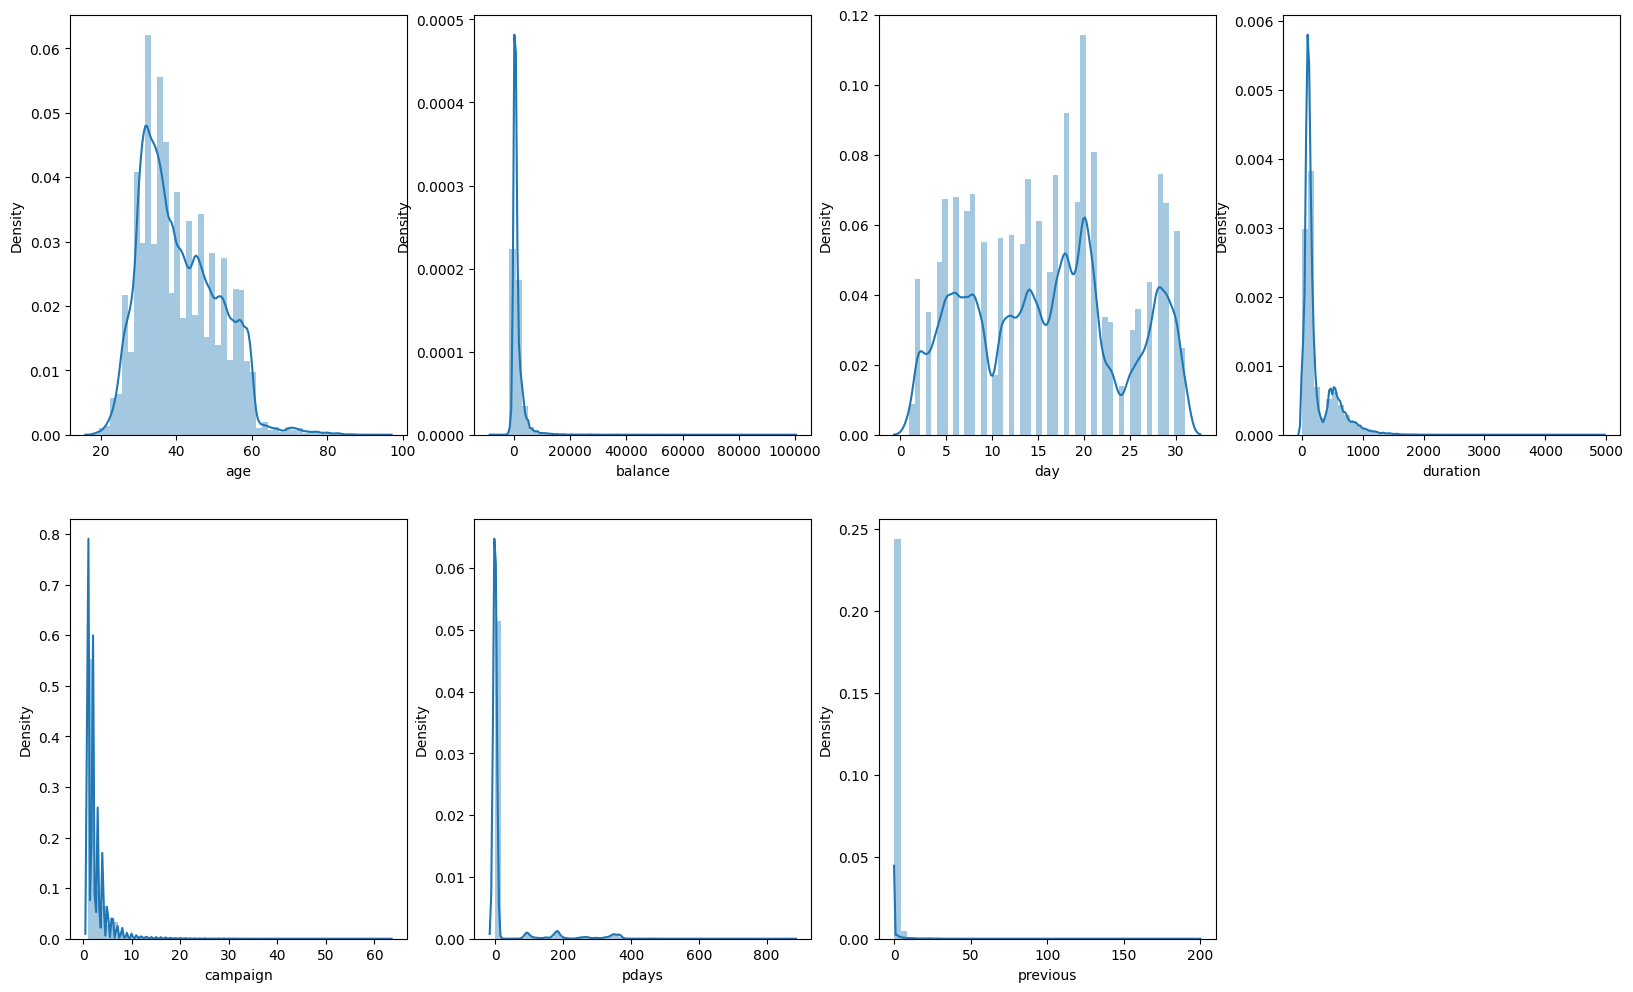

In [10]:
# Plotting "Distplot" to see if the distribution of a column normal or skewed
plt.figure(figsize=(20,12))
plt.subplot(2,4,1)
sns.distplot(num_col['age'])

plt.subplot(2,4,2)
sns.distplot(num_col['balance'])

plt.subplot(2,4,3)
sns.distplot(num_col['day'])

plt.subplot(2,4,4)
sns.distplot(num_col['duration'])

plt.subplot(2,4,5)
sns.distplot(num_col['campaign'])

plt.subplot(2,4,6)
sns.distplot(num_col['pdays'])

plt.subplot(2,4,7)
sns.distplot(num_col['previous'])

**We can see that we've alot of right skewed columns except for the day column**

In [11]:
num_col.skew() # Skewness of numerical columns quantity wise

age          0.586137
balance     12.304123
day          0.054014
duration     2.048776
campaign     4.810437
pdays        3.625049
previous    13.749885
y            2.329296
dtype: float64

<Axes: >

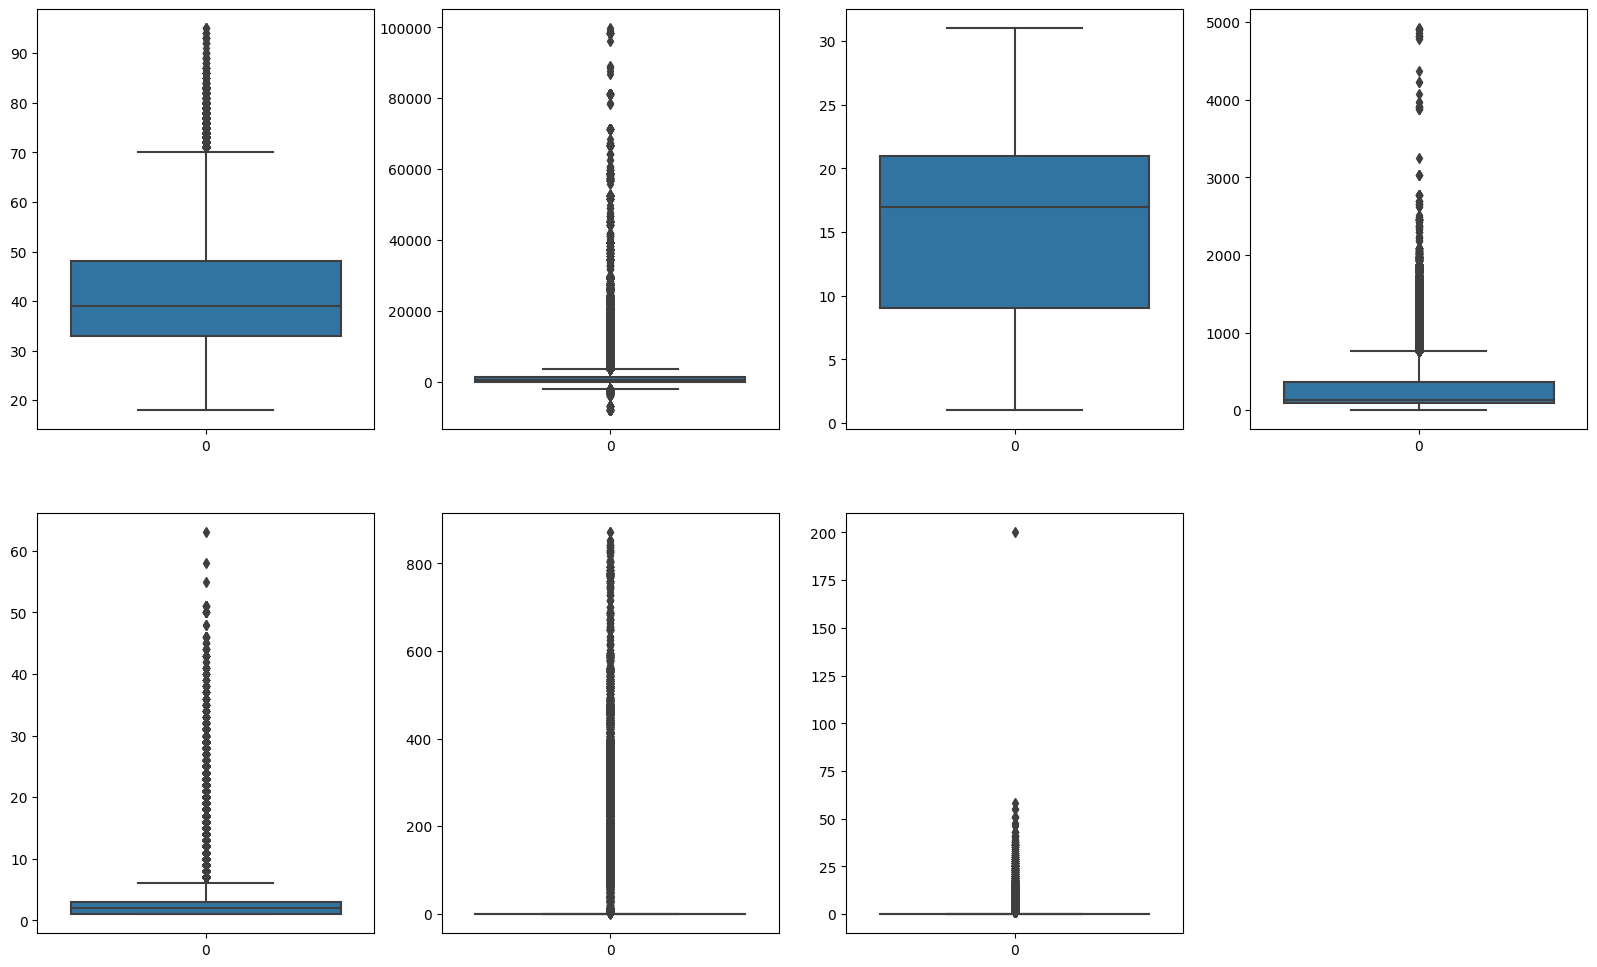

In [12]:
# Plotting "Boxplot" to see if there are outliers in our numerical columns or not
plt.figure(figsize=(20,12))
plt.subplot(2,4,1)
sns.boxplot(num_col['age'])

plt.subplot(2,4,2)
sns.boxplot(num_col['balance'])

plt.subplot(2,4,3)
sns.boxplot(num_col['day'])

plt.subplot(2,4,4)
sns.boxplot(num_col['duration'])

plt.subplot(2,4,5)
sns.boxplot(num_col['campaign'])

plt.subplot(2,4,6)
sns.boxplot(num_col['pdays'])

plt.subplot(2,4,7)
sns.boxplot(num_col['previous'])

**This graph shows we have alot of outliers as well in our numerical columns**

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  

<Axes: xlabel='poutcome', ylabel='Count'>

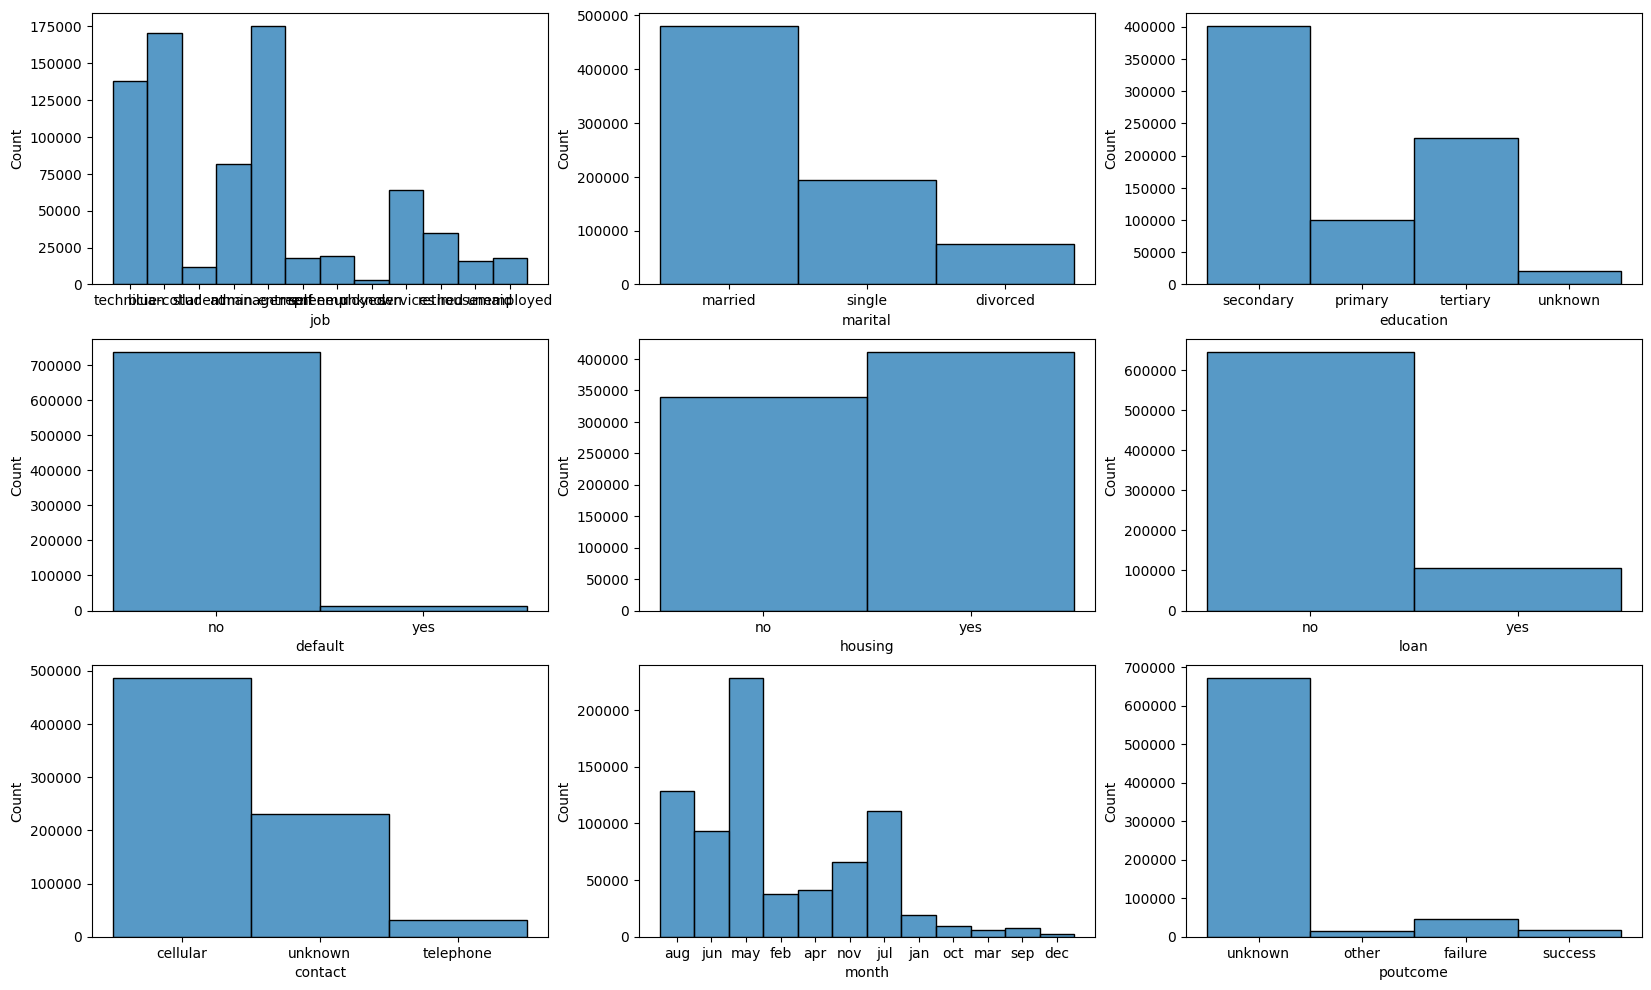

In [13]:
# Plotting 'Histplot' to see the distribution of numbers/values among classes
plt.figure(figsize=(20,12))
plt.subplot(3,3,1)
sns.histplot(cat_col['job'])

plt.subplot(3,3,2)
sns.histplot(cat_col['marital'])

plt.subplot(3,3,3)
sns.histplot(cat_col['education'])

plt.subplot(3,3,4)
sns.histplot(cat_col['default'])

plt.subplot(3,3,5)
sns.histplot(cat_col['housing'])

plt.subplot(3,3,6)
sns.histplot(cat_col['loan'])

plt.subplot(3,3,7)
sns.histplot(cat_col['contact'])

plt.subplot(3,3,8)
sns.histplot(cat_col['month'])

plt.subplot(3,3,9)
sns.histplot(cat_col['poutcome'])

In [14]:
cat_col['default'].value_counts() # To show you how big the gap is among the default classes

default
no     737151
yes     12849
Name: count, dtype: int64

**I'm gonna drop the  default column because of a huge class difference or imbalancement while the rest  of the columns will still be useful**

In [15]:
# Droping the default column from both the df_train dataset as well as cat_col dataset
df_train.drop(columns=['default'],inplace=True)
cat_col.drop(columns=['default'],inplace=True)

In [16]:
#sns.pairplot(num_col)

**You can plot the above pairplot graph which shows the non_linear behaviour of numerical columns**

## Transformers

In [17]:
df_train.head(3)

,age,job,marital,education,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,42,technician,married,secondary,7,no,no,cellular,25,aug,117,3,-1,0,unknown,0
1,38,blue-collar,married,secondary,514,no,no,unknown,18,jun,185,1,-1,0,unknown,0
2,36,blue-collar,married,secondary,602,yes,no,unknown,14,may,111,2,-1,0,unknown,0


In [18]:
# To confirm if the num_col contains the negatice values
for col in num_col.columns:
    if (num_col[col] <  0).any():
        print(f"Column '{col}' has negative values")
    else:
        print(f"Column '{col}' has no negative values")

Column 'age' has no negative values
Column 'balance' has negative values
Column 'day' has no negative values
Column 'duration' has no negative values
Column 'campaign' has no negative values
Column 'pdays' has negative values
Column 'previous' has no negative values
Column 'y' has no negative values


**Only balance and pdays columns have negative values in them**

In [19]:
trf = ColumnTransformer([
    ("KBins", KBinsDiscretizer(n_bins=15, encode='ordinal', strategy='quantile'), [0,4,8,10,11,12,13]), # Transforming continuous values of a column to discrete values(also reduce outleirs affect to some extent)
    ("OneHot", OneHotEncoder(drop='first', sparse_output=False, dtype='int64'), [1,5,6,7,14]), # Transforming the categorical values(having no order b/w them) to numeric values
    ("Ordina", OrdinalEncoder(), [2,3,9]), # Transforming the categorical values(having some sort of order b/w them) to numeric values
("FunctionTransformer", FunctionTransformer(func=np.log1p), [0,8,10,11,13]), # For right skewed numerical columns
("PowerTransformer", PowerTransformer(method='yeo-johnson',standardize=True ), [4,12]) # For  the columns having negative values in them

])


We are performing different transformations on our dataset based on what kind of data we have.
#### Dataset:
1) **We've categorical columns: on which we're performing two kinds of transformations**.
* OneHot_Encoding: for the columns who don't have any kind of order among their categories
* Ordinal_Encoding: for the columns who have some sort of order among their categories

              
2) **We've numeric columns: on which we're performing three kinds of transformations**.
* KBinsDiscretizer: for the numeric columns to convert them from continuous values into categories like for age column 0-10,20-30 etc
* Function_Transformer: for the columns are right skewed and applicable only on  those columns who values greater than 0(values > 0)
* Power_Transformer: for the columns who have any kind of values like greater than or equal to zero (0 < values > 0)

## Train Test Split

In [20]:
X1=df_train.drop(columns=['y'])
y1=df_train['y']
X_train,X_test,y_train,y_test=train_test_split(X1,y1,test_size=0.2,random_state=43)
print('Training Data Shape: ',X_train.shape)
print('Testning Data Shape: ',X_test.shape)


Training Data Shape:  (600000, 15)
Testning Data Shape:  (150000, 15)


### Models

In [21]:
lr=LogisticRegression(penalty='l2',max_iter=150,solver='saga',random_state=43,n_jobs=-1,l1_ratio=0.75)
dt=DecisionTreeClassifier(splitter='best',max_depth=45)
rf=RandomForestClassifier(n_estimators=250, max_depth=45,n_jobs=-1,max_features=0.25,bootstrap=True)

### Pipeline & Evaluation

In [22]:
pipe=Pipeline([
               ('trf',trf),
               ('lr',lr)])
pipe.fit(X_train,y_train)

/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_discretization.py:216: FutureWarning: In version 1.3 onwards, subsample=2e5 will be used by default. Set subsample explicitly to silence this warning in the mean time. Set subsample=None to disable subsampling explicitly.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_discretization.py:279: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 4 are removed. Consider decreasing the number of bins.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_discretization.py:279: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 5 are removed. Consider decreasing the number of bins.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_discretization.py:279: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 6 are removed. Consider decreasing the number of bins.
  warnings.warn(
/usr/local/

Pipeline(steps=[('trf',
                 ColumnTransformer(transformers=[('KBins',
                                                  KBinsDiscretizer(encode='ordinal',
                                                                   n_bins=15),
                                                  [0, 4, 8, 10, 11, 12, 13]),
                                                 ('OneHot',
                                                  OneHotEncoder(drop='first',
                                                                dtype='int64',
                                                                sparse_output=False),
                                                  [1, 5, 6, 7, 14]),
                                                 ('Ordina', OrdinalEncoder(),
                                                  [2, 3, 9]),
                                                 ('FunctionTransformer',
                                                  FunctionTransformer(func=<ufunc 'log1p'>),
                                                  [0, 8, 10, 11, 13]),
                                                 ('PowerTransformer',
                                                  PowerTransformer(),
                                                  [4, 12])])),
                ('lr',
                 LogisticRegression(l1_ratio=0.75, max_iter=150, n_jobs=-1,
                                    random_state=43, solver='saga'))])

In [23]:
roc_auc_score(y_test,pipe.predict(X_test))

0.7296601627135934

In [24]:
pipe1=Pipeline([
               ('trf',trf),
               ('dt',dt)])
pipe1.fit(X_train,y_train)

/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_discretization.py:216: FutureWarning: In version 1.3 onwards, subsample=2e5 will be used by default. Set subsample explicitly to silence this warning in the mean time. Set subsample=None to disable subsampling explicitly.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_discretization.py:279: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 4 are removed. Consider decreasing the number of bins.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_discretization.py:279: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 5 are removed. Consider decreasing the number of bins.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_discretization.py:279: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 6 are removed. Consider decreasing the number of bins.
  warnings.warn(


Pipeline(steps=[('trf',
                 ColumnTransformer(transformers=[('KBins',
                                                  KBinsDiscretizer(encode='ordinal',
                                                                   n_bins=15),
                                                  [0, 4, 8, 10, 11, 12, 13]),
                                                 ('OneHot',
                                                  OneHotEncoder(drop='first',
                                                                dtype='int64',
                                                                sparse_output=False),
                                                  [1, 5, 6, 7, 14]),
                                                 ('Ordina', OrdinalEncoder(),
                                                  [2, 3, 9]),
                                                 ('FunctionTransformer',
                                                  FunctionTransformer(func=<ufunc 'log1p'>),
                                                  [0, 8, 10, 11, 13]),
                                                 ('PowerTransformer',
                                                  PowerTransformer(),
                                                  [4, 12])])),
                ('dt', DecisionTreeClassifier(max_depth=45))])

In [25]:
roc_auc_score(y_test,pipe1.predict(X_test))

0.7825397427845127

In [26]:
pipe2=Pipeline([
               ('trf',trf),
               ('rf',rf)])
pipe2.fit(X_train,y_train)

/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_discretization.py:216: FutureWarning: In version 1.3 onwards, subsample=2e5 will be used by default. Set subsample explicitly to silence this warning in the mean time. Set subsample=None to disable subsampling explicitly.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_discretization.py:279: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 4 are removed. Consider decreasing the number of bins.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_discretization.py:279: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 5 are removed. Consider decreasing the number of bins.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_discretization.py:279: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 6 are removed. Consider decreasing the number of bins.
  warnings.warn(


Pipeline(steps=[('trf',
                 ColumnTransformer(transformers=[('KBins',
                                                  KBinsDiscretizer(encode='ordinal',
                                                                   n_bins=15),
                                                  [0, 4, 8, 10, 11, 12, 13]),
                                                 ('OneHot',
                                                  OneHotEncoder(drop='first',
                                                                dtype='int64',
                                                                sparse_output=False),
                                                  [1, 5, 6, 7, 14]),
                                                 ('Ordina', OrdinalEncoder(),
                                                  [2, 3, 9]),
                                                 ('FunctionTransformer',
                                                  FunctionTransformer(func=<ufunc 'log1p'>),
                                                  [0, 8, 10, 11, 13]),
                                                 ('PowerTransformer',
                                                  PowerTransformer(),
                                                  [4, 12])])),
                ('rf',
                 RandomForestClassifier(max_depth=45, max_features=0.25,
                                        n_estimators=250, n_jobs=-1))])

In [27]:
roc_auc_score(y_test,pipe2.predict(X_test))

0.8123797523039372

# Submission

In [28]:

submission=pd.DataFrame({
    'id':df_test['id'],
    'y':pipe2.predict(df_test)
})

submission.to_csv('submission.csv',index=False)

In [29]:
df=pd.read_csv('submission.csv')
df

,id,y
0,750000,0
1,750001,0
2,750002,0
3,750003,0
4,750004,0
...,...,...
249995,999995,0
249996,999996,0
249997,999997,1
249998,999998,0
